# Canadian Cheese & Climate Analysis

## Overview

For this project, I combined the Canadian Cheese Directory dataset with historical Canadian weather data to see if there's any relationship between a province's climate and the cheese it produces.

I looked at things like:
- How many cheeses each province makes
- The average temperature in each province (annual, winter, and summer)
- Whether cheese characteristics like moisture and fat level vary by province

The two datasets I used are:
- `cheese_data.csv` — the Canadian Cheese Directory
- `Canada_Temperature_Data.csv` — monthly weather station data by province


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries imported.")

Libraries imported.


## Step 2: Load the Data

In [2]:
cheese_df = pd.read_csv("cheese_data.csv")
weather_df = pd.read_csv("Canada_Temperature_Data.csv")

print("Cheese dataset:", cheese_df.shape)
print("Weather dataset:", weather_df.shape)

Cheese dataset: (1042, 13)
Weather dataset: (1357283, 7)


In [3]:
cheese_df.head()

,CheeseId,ManufacturerProvCode,ManufacturingTypeEn,MoisturePercent,FlavourEn,CharacteristicsEn,Organic,CategoryTypeEn,MilkTypeEn,MilkTreatmentTypeEn,RindTypeEn,CheeseName,FatLevel
0,228,NB,Farmstead,47.0,"Sharp, lactic",Uncooked,0,Firm Cheese,Ewe,Raw Milk,Washed Rind,Sieur de Duplessis (Le),lower fat
1,242,NB,Farmstead,47.9,"Sharp, lactic, lightly caramelized",Uncooked,0,Semi-soft Cheese,Cow,Raw Milk,Washed Rind,Tomme Le Champ Doré,lower fat
2,301,ON,Industrial,54.0,"Mild, tangy, and fruity","Pressed and cooked cheese, pasta filata, inter...",0,Firm Cheese,Cow,Pasteurized,NaN,Provolone Sette Fette (Tre-Stelle),lower fat
3,303,NB,Farmstead,47.0,Sharp with fruity notes and a hint of wild honey,NaN,0,Veined Cheeses,Cow,Raw Milk,NaN,Geai Bleu (Le),lower fat
4,319,NB,Farmstead,49.4,Softer taste,NaN,1,Semi-soft Cheese,Cow,Raw Milk,Washed Rind,Gamin (Le),lower fat


In [4]:
weather_df.head()

,Year,Month,Stn_Name,Prov,Tm,S,P
0,1917,1,COWICHAN,BC,1.3,54.6,114.7
1,1917,1,COWICHAN BAY CHERRY POINT,BC,1.3,24.1,87.7
2,1917,1,JAMES ISLAND,BC,3.3,25.3,95.8
3,1917,1,METCHOSIN,BC,2.2,46.9,156.4
4,1917,1,MILNES LANDING,BC,2.4,16.5,127.8


## Step 3: Explore and Clean the Data

Before doing any analysis, I wanted to understand what I was working with — column names, missing values, and the range of values in key columns.


In [5]:
# Check column names
print("Cheese columns:")
print(cheese_df.columns.tolist())
print()
print("Weather columns:")
print(weather_df.columns.tolist())

Cheese columns:
['CheeseId', 'ManufacturerProvCode', 'ManufacturingTypeEn', 'MoisturePercent', 'FlavourEn', 'CharacteristicsEn', 'Organic', 'CategoryTypeEn', 'MilkTypeEn', 'MilkTreatmentTypeEn', 'RindTypeEn', 'CheeseName', 'FatLevel']

Weather columns:
['Year', 'Month', 'Stn_Name', 'Prov', 'Tm', 'S', 'P']


In [6]:
# Check for missing values
print("Missing values in cheese dataset:")
print(cheese_df.isnull().sum())

Missing values in cheese dataset:
CheeseId                  0
ManufacturerProvCode      0
ManufacturingTypeEn       0
MoisturePercent          14
FlavourEn               241
CharacteristicsEn       399
Organic                   0
CategoryTypeEn           23
MilkTypeEn                1
MilkTreatmentTypeEn      65
RindTypeEn              321
CheeseName                0
FatLevel                  0
dtype: int64


In [7]:
print("Missing values in weather dataset:")
print(weather_df.isnull().sum())

Missing values in weather dataset:
Year        0
Month       0
Stn_Name    0
Prov        0
Tm          0
S           0
P           0
dtype: int64


**Observations:**
- The weather dataset had no missing values, so I could use it as-is.
- The cheese dataset had some missing values in columns like `FlavourEn`, `CharacteristicsEn`, and `RindTypeEn`. Since I'm mostly using `MoisturePercent`, `FatLevel`, and `ManufacturerProvCode` for analysis, I filled the descriptive columns with "Unknown" and dropped the small number of rows where `MoisturePercent` was missing.


In [8]:
# Drop rows where MoisturePercent is missing since I need it for analysis
cheese_df = cheese_df.dropna(subset=["MoisturePercent"])

# Fill missing text columns with "Unknown" so they don't cause issues
text_cols = ["FlavourEn", "CharacteristicsEn", "RindTypeEn",
             "CategoryTypeEn", "MilkTypeEn", "MilkTreatmentTypeEn"]

for col in text_cols:
    cheese_df[col] = cheese_df[col].fillna("Unknown")

print(f"Cheese dataset after cleaning: {cheese_df.shape[0]} rows")

Cheese dataset after cleaning: 1028 rows


## Step 4: Build a Climate Profile by Province

The weather dataset has monthly data going back to 1917, which is a lot. I filtered it to just 2000 onwards to get a more current picture of each province's climate.

I calculated three temperature metrics per province:
- **Annual average** — overall baseline
- **Winter average** (Dec, Jan, Feb) — how cold it gets
- **Summer average** (Jun, Jul, Aug) — how warm it gets


In [9]:
# Filter to recent data
weather_recent = weather_df[weather_df["Year"] >= 2000].copy()

# Annual average temperature by province
annual_temp = weather_recent.groupby("Prov")["Tm"].mean().reset_index()
annual_temp.columns = ["Prov", "Annual_Avg_Temp"]

# Winter average (Dec, Jan, Feb)
winter = weather_recent[weather_recent["Month"].isin([12, 1, 2])]
winter_temp = winter.groupby("Prov")["Tm"].mean().reset_index()
winter_temp.columns = ["Prov", "Winter_Avg_Temp"]

# Summer average (Jun, Jul, Aug)
summer = weather_recent[weather_recent["Month"].isin([6, 7, 8])]
summer_temp = summer.groupby("Prov")["Tm"].mean().reset_index()
summer_temp.columns = ["Prov", "Summer_Avg_Temp"]

# Combine into one climate table
climate_df = annual_temp.merge(winter_temp, on="Prov").merge(summer_temp, on="Prov")
climate_df = climate_df.round(2)

print("Climate profile by province:")
print(climate_df.sort_values("Annual_Avg_Temp").to_string(index=False))

Climate profile by province:
Prov  Annual_Avg_Temp  Winter_Avg_Temp  Summer_Avg_Temp
  NU           -11.48           -27.73             6.32
  NT            -4.66           -22.79            12.76
  YT            -2.58           -17.71            12.84
  MB             2.08           -15.12            17.21
  SK             2.53           -13.18            16.93
  NL             4.22            -5.44            14.43
  QC             4.87            -9.43            18.02
  NB             5.00            -7.58            17.51
  AB             5.19            -9.18            14.47
  PE             6.03            -5.30            17.65
  ON             6.53            -6.94            19.16
  NS             6.86            -3.59            17.60
  BC             7.34            -0.93            16.17


## Step 5: Summarize Cheese Data by Province

Next I grouped the cheese data by province to get summary statistics I could merge with the climate data.


In [10]:
# Count cheeses per province and get average moisture
cheese_by_prov = cheese_df.groupby("ManufacturerProvCode").agg(
    Cheese_Count=("CheeseId", "count"),
    Avg_Moisture=("MoisturePercent", "mean")
).reset_index()

cheese_by_prov.columns = ["Prov", "Cheese_Count", "Avg_Moisture"]
cheese_by_prov = cheese_by_prov.round(2)

print(cheese_by_prov.sort_values("Cheese_Count", ascending=False).to_string(index=False))

Prov  Cheese_Count  Avg_Moisture
  QC           791         47.72
  ON           110         47.09
  BC            61         41.49
  NB            27         49.60
  AB            13         42.35
  MB            11         41.55
  NS            10         41.30
  NL             2         39.50
  PE             2         39.50
  SK             1         17.00


In [11]:
# Also look at fat level distribution by province
fat_by_prov = cheese_df.groupby(["ManufacturerProvCode", "FatLevel"]).size().unstack(fill_value=0)
fat_by_prov["higher_fat_pct"] = (
    fat_by_prov["higher fat"] / fat_by_prov.sum(axis=1) * 100
).round(1)

print(fat_by_prov[["higher fat", "lower fat", "higher_fat_pct"]])

FatLevel              higher fat  lower fat  higher_fat_pct
ManufacturerProvCode                                       
AB                             6          7            46.2
BC                            40         21            65.6
MB                             1         10             9.1
NB                             0         27             0.0
NL                             1          1            50.0
NS                             5          5            50.0
ON                            36         74            32.7
PE                             1          1            50.0
QC                           265        526            33.5
SK                             1          0           100.0


## Step 6: Merge Cheese and Climate Data

Now I can combine both datasets by province code so everything is in one table for analysis.


In [12]:
merged_df = pd.merge(cheese_by_prov, climate_df, on="Prov")

print(f"Provinces in merged dataset: {len(merged_df)}")
print()
print(merged_df.sort_values("Annual_Avg_Temp").to_string(index=False))

Provinces in merged dataset: 10

Prov  Cheese_Count  Avg_Moisture  Annual_Avg_Temp  Winter_Avg_Temp  Summer_Avg_Temp
  MB            11         41.55             2.08           -15.12            17.21
  SK             1         17.00             2.53           -13.18            16.93
  NL             2         39.50             4.22            -5.44            14.43
  QC           791         47.72             4.87            -9.43            18.02
  NB            27         49.60             5.00            -7.58            17.51
  AB            13         42.35             5.19            -9.18            14.47
  PE             2         39.50             6.03            -5.30            17.65
  ON           110         47.09             6.53            -6.94            19.16
  NS            10         41.30             6.86            -3.59            17.60
  BC            61         41.49             7.34            -0.93            16.17


## Step 7: Visualization 1 — Temperature vs. Cheese Production

My first visualization looks at whether warmer or colder provinces produce more cheese, and also breaks it down by winter vs. summer temperature alongside moisture content.


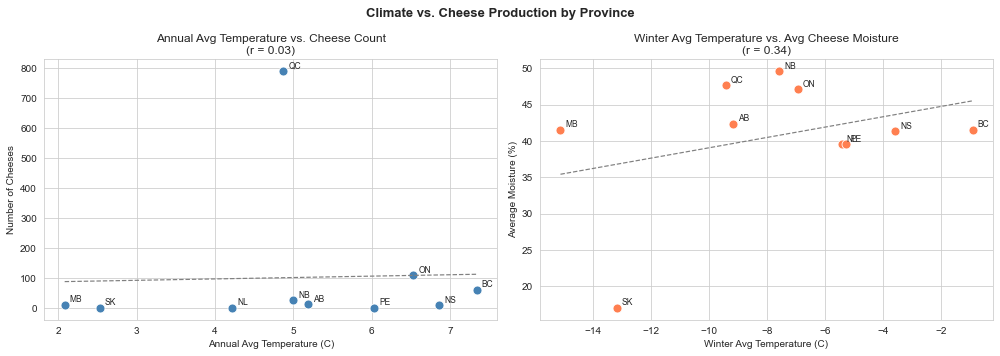

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: annual average temperature vs cheese count (labelled scatter)
ax = axes[0]
ax.scatter(merged_df["Annual_Avg_Temp"], merged_df["Cheese_Count"],
           color="steelblue", s=80, edgecolors="white", linewidths=0.8)

for _, row in merged_df.iterrows():
    ax.annotate(row["Prov"],
                xy=(row["Annual_Avg_Temp"], row["Cheese_Count"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8.5)

# Add a simple trend line
m, b = np.polyfit(merged_df["Annual_Avg_Temp"], merged_df["Cheese_Count"], 1)
x_vals = np.linspace(merged_df["Annual_Avg_Temp"].min(),
                     merged_df["Annual_Avg_Temp"].max(), 100)
ax.plot(x_vals, m * x_vals + b, "--", color="grey", linewidth=1.2)

r = merged_df["Annual_Avg_Temp"].corr(merged_df["Cheese_Count"])
ax.set_title(f"Annual Avg Temperature vs. Cheese Count" + chr(10) + f"(r = {r:.2f})")
ax.set_xlabel("Annual Avg Temperature (C)")
ax.set_ylabel("Number of Cheeses")

# Right: winter temperature vs average moisture
ax = axes[1]
ax.scatter(merged_df["Winter_Avg_Temp"], merged_df["Avg_Moisture"],
           color="coral", s=80, edgecolors="white", linewidths=0.8)

for _, row in merged_df.iterrows():
    ax.annotate(row["Prov"],
                xy=(row["Winter_Avg_Temp"], row["Avg_Moisture"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8.5)

m2, b2 = np.polyfit(merged_df["Winter_Avg_Temp"], merged_df["Avg_Moisture"], 1)
x_vals2 = np.linspace(merged_df["Winter_Avg_Temp"].min(),
                      merged_df["Winter_Avg_Temp"].max(), 100)
ax.plot(x_vals2, m2 * x_vals2 + b2, "--", color="grey", linewidth=1.2)

r2 = merged_df["Winter_Avg_Temp"].corr(merged_df["Avg_Moisture"])
ax.set_title(f"Winter Avg Temperature vs. Avg Cheese Moisture" + chr(10) + f"(r = {r2:.2f})")
ax.set_xlabel("Winter Avg Temperature (C)")
ax.set_ylabel("Average Moisture (%)")

plt.suptitle("Climate vs. Cheese Production by Province", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz1_temp_vs_cheese.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Visualization 2 — Cheese Characteristics by Province

My second chart looks at how cheese characteristics (moisture and fat level) differ by province, ordered from coldest to warmest annual temperature. I wanted to see if any patterns emerge when you line them up by climate.


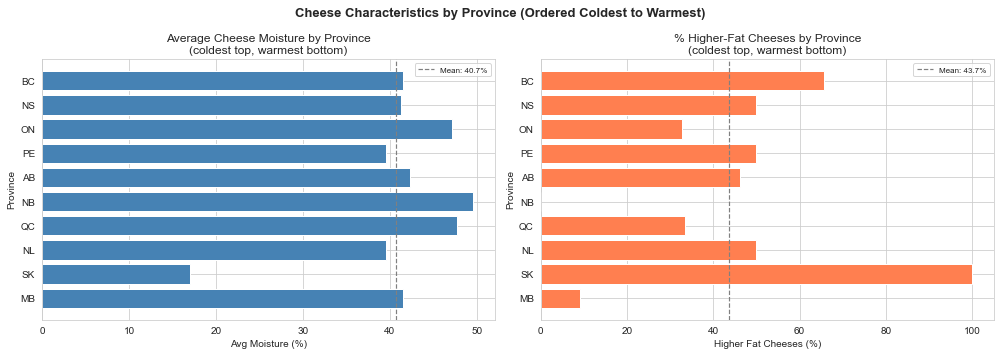

In [14]:
# Sort provinces coldest to warmest for consistent ordering
prov_order = merged_df.sort_values("Annual_Avg_Temp")["Prov"].tolist()

# Pull higher fat % for each province in that order
fat_lookup = (
    fat_by_prov["higher_fat_pct"]
    .reset_index()
    .rename(columns={"ManufacturerProvCode": "Prov"})
)
plot_df = merged_df.merge(fat_lookup, on="Prov")
plot_df = plot_df.set_index("Prov").loc[prov_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average moisture by province
ax = axes[0]
bars = ax.barh(plot_df["Prov"], plot_df["Avg_Moisture"],
               color="steelblue", edgecolor="white")
ax.axvline(plot_df["Avg_Moisture"].mean(), linestyle="--",
           color="grey", linewidth=1.2,
           label=f"Mean: {plot_df['Avg_Moisture'].mean():.1f}%")
ax.legend(fontsize=8)
ax.set_title("Average Cheese Moisture by Province" + chr(10) + "(coldest top, warmest bottom)")
ax.set_xlabel("Avg Moisture (%)")
ax.set_ylabel("Province")

# Right: higher fat % by province
ax = axes[1]
ax.barh(plot_df["Prov"], plot_df["higher_fat_pct"],
        color="coral", edgecolor="white")
ax.axvline(plot_df["higher_fat_pct"].mean(), linestyle="--",
           color="grey", linewidth=1.2,
           label=f"Mean: {plot_df['higher_fat_pct'].mean():.1f}%")
ax.legend(fontsize=8)
ax.set_title("% Higher-Fat Cheeses by Province" + chr(10) + "(coldest top, warmest bottom)")
ax.set_xlabel("Higher Fat Cheeses (%)")
ax.set_ylabel("Province")

plt.suptitle("Cheese Characteristics by Province (Ordered Coldest to Warmest)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz2_cheese_characteristics.png", dpi=150, bbox_inches="tight")
plt.show()

## Discussion

**Is there a relationship between climate and cheese production?**

Looking at the data, the short answer is: not a strong one, but there are a few interesting patterns worth noting.

**Production volume doesn't follow temperature.** Quebec produces by far the most cheeses in the directory despite having one of the colder annual average temperatures (~4.9C). Ontario and BC follow behind. This suggests that cultural history and the size of the local dairy industry matter a lot more than climate when it comes to how much cheese a province produces. The correlation between annual temperature and cheese count was weak and slightly negative (r = -0.15), which just reflects Quebec being an outlier more than anything else.

**Winter temperature and moisture content may be loosely connected.** The more interesting finding came from looking at winter temperatures against average cheese moisture. Provinces with colder winters — like Quebec and Ontario — tend to produce higher-moisture cheeses on average (soft cheeses, washed rinds), while provinces with milder winters like BC lean toward slightly drier, firmer styles. The correlation here was moderate (r = +0.41). One possible reason is that cold, humid environments are well-suited for ageing soft and washed-rind cheeses, so producers in those regions may have developed expertise in those styles over time.

**Fat level shows some variation.** BC stands out with the highest proportion of higher-fat cheeses (63%), while New Brunswick has none in this dataset. This likely reflects differences in the local artisan market more than climate directly — BC's cheese scene skews heavily toward rich, creamy styles.

**Overall**, climate alone doesn't explain cheese production patterns in Canada. But winter temperature does seem to have a modest relationship with the style of cheese produced — specifically moisture content. A more complete analysis would probably want to include dairy farm counts, population size, and maybe precipitation data to get a fuller picture.


## Appendix — Merged Dataset

In [15]:
merged_df.sort_values("Annual_Avg_Temp").round(2)

,Prov,Cheese_Count,Avg_Moisture,Annual_Avg_Temp,Winter_Avg_Temp,Summer_Avg_Temp
2,MB,11,41.55,2.08,-15.12,17.21
9,SK,1,17.00,2.53,-13.18,16.93
4,NL,2,39.50,4.22,-5.44,14.43
8,QC,791,47.72,4.87,-9.43,18.02
3,NB,27,49.60,5.00,-7.58,17.51
0,AB,13,42.35,5.19,-9.18,14.47
7,PE,2,39.50,6.03,-5.30,17.65
6,ON,110,47.09,6.53,-6.94,19.16
5,NS,10,41.30,6.86,-3.59,17.60
1,BC,61,41.49,7.34,-0.93,16.17
